# Basic Backtesting

This notebook is used to demonstrate how to perform backtesting on a simple trading algorithm: the moving average. This notebook should serve as a tutorial for those who wish to use this repository to further test different strategies.

We start off by installing the needed packages to perform this backtest:

- NumPy is a standard for complex calculations with series
- Pandas is a standard when dealing with tables of data (referred to as DataFrames)
- YFinance helps when downloading historical market data
- Matplotlib is a standard for basic plotting in Python
- datetime assists in performing mathematical calculation between dates and for converting dates into timestamps

In [82]:
import numpy as np
import pandas as pd
import yfinance as yf
from matplotlib import pyplot as plt
from datetime import datetime

Second, we define our initial variables for the backtest, which include the starting balance and the period to observe this moving average. We then extract the market information from Yahoo Finance for a specific ticker over a certain period of time.

In [83]:
starting_balance = 1000
period = 200

In [84]:
# Extract Daily Data
start = datetime(2014,1,1)
end = datetime(2026,1,1)
ticker = "MSFT"
interval = "1d"

In [85]:
price = yf.download(tickers=ticker, start=start, end=end, interval=interval, multi_level_index=False)

price

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,30.694437,30.892680,30.644875,30.851377,30632200
2014-01-03,30.487940,30.744003,30.231876,30.727483,31134800
2014-01-06,29.843655,30.471419,29.827134,30.438378,43603700
2014-01-07,30.074926,30.141008,29.909724,30.008847,35802800
2014-01-08,29.538033,29.851916,29.389354,29.736276,59971700
...,...,...,...,...,...
2025-12-24,485.856323,486.991284,482.680464,483.526701,5855900
2025-12-26,485.547729,485.955915,483.805488,484.552163,8842200
2025-12-29,484.940430,486.184888,482.033362,482.710340,10893400


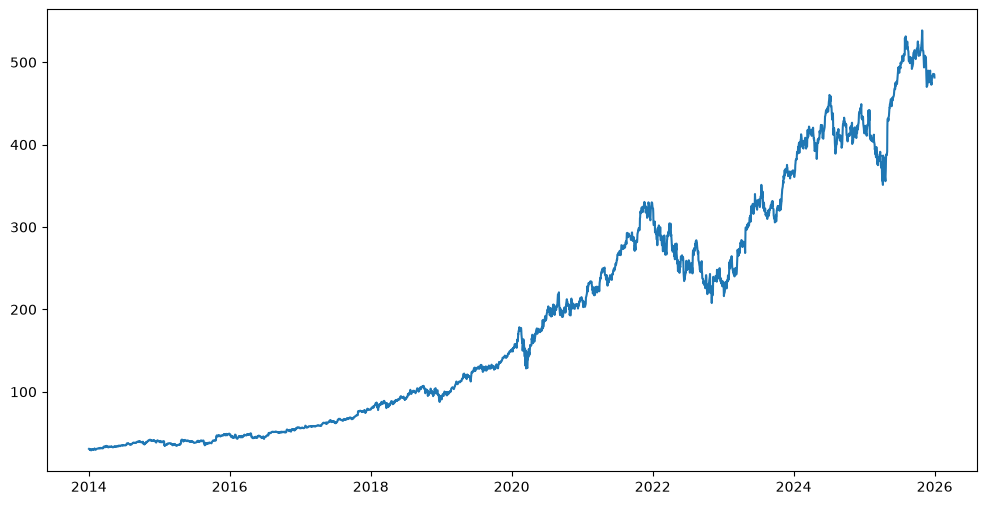

In [86]:
plt.figure(figsize=[12,6])
plt.plot(price['Close'])

We then use this data as a benchmark to calculate daily returns, CAGR (Compound Annual Growth Rate), and DD (drawdown). This benchmark will be tested against the strategy to determine the strategy's effectiveness.

In [87]:
# Calculate daily returns
price['Return'] = price.Close / price.Close.shift(1)
price.Return.iat[0] = 1
price['Bench_Bal'] = starting_balance * price.Return.cumprod()

price

,Close,High,Low,Open,Volume,Return,Bench_Bal
Date,,,,,,,
2014-01-02,30.694437,30.892680,30.644875,30.851377,30632200,1.000000,1000.000000
2014-01-03,30.487940,30.744003,30.231876,30.727483,31134800,0.993272,993.272488
2014-01-06,29.843655,30.471419,29.827134,30.438378,43603700,0.978868,972.282196
2014-01-07,30.074926,30.141008,29.909724,30.008847,35802800,1.007749,979.816843
2014-01-08,29.538033,29.851916,29.389354,29.736276,59971700,0.982148,962.325274
...,...,...,...,...,...,...,...
2025-12-24,485.856323,486.991284,482.680464,483.526701,5855900,1.002403,15828.807116
2025-12-26,485.547729,485.955915,483.805488,484.552163,8842200,0.999365,15818.753381
2025-12-29,484.940430,486.184888,482.033362,482.710340,10893400,0.998749,15798.968043


In [88]:
first_time = price.index.min()
last_time = price.index.max()

# Calculate the number of years
years = (last_time - first_time).days / 365.25

price['Bench_Peak'] = price.Bench_Bal.cummax()
price['Bench_DD'] = price.Bench_Bal - price.Bench_Peak

cagr_bench = round(((price.Bench_Bal.iloc[-1] / price.Bench_Bal.iloc[0]) ** (1/years)) * 100, 2)
dd_bench = round(((price.Bench_DD / price.Bench_Peak).min()) * 100, 2)

print(f"Benchmark Annual Return: {cagr_bench}")
print(f"Benchmark DD: {dd_bench}")

Benchmark Annual Return: 125.8
Benchmark DD: -37.15


In [89]:
# Calculate indicators
price['MA'] = price.Close.rolling(window=period).mean()

price['Long'] = price.Close > price.MA

price

,Close,High,Low,Open,Volume,Return,Bench_Bal,Bench_Peak,Bench_DD,MA,Long
Date,,,,,,,,,,,
2014-01-02,30.694437,30.892680,30.644875,30.851377,30632200,1.000000,1000.000000,1000.000000,0.000000,NaN,False
2014-01-03,30.487940,30.744003,30.231876,30.727483,31134800,0.993272,993.272488,1000.000000,-6.727512,NaN,False
2014-01-06,29.843655,30.471419,29.827134,30.438378,43603700,0.978868,972.282196,1000.000000,-27.717804,NaN,False
2014-01-07,30.074926,30.141008,29.909724,30.008847,35802800,1.007749,979.816843,1000.000000,-20.183157,NaN,False
2014-01-08,29.538033,29.851916,29.389354,29.736276,59971700,0.982148,962.325274,1000.000000,-37.674726,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,485.856323,486.991284,482.680464,483.526701,5855900,1.002403,15828.807116,17549.061703,-1720.254587,472.093603,True
2025-12-26,485.547729,485.955915,483.805488,484.552163,8842200,0.999365,15818.753381,17549.061703,-1730.308323,472.623662,True
2025-12-29,484.940430,486.184888,482.033362,482.710340,10893400,0.998749,15798.968043,17549.061703,-1750.093660,473.172964,True


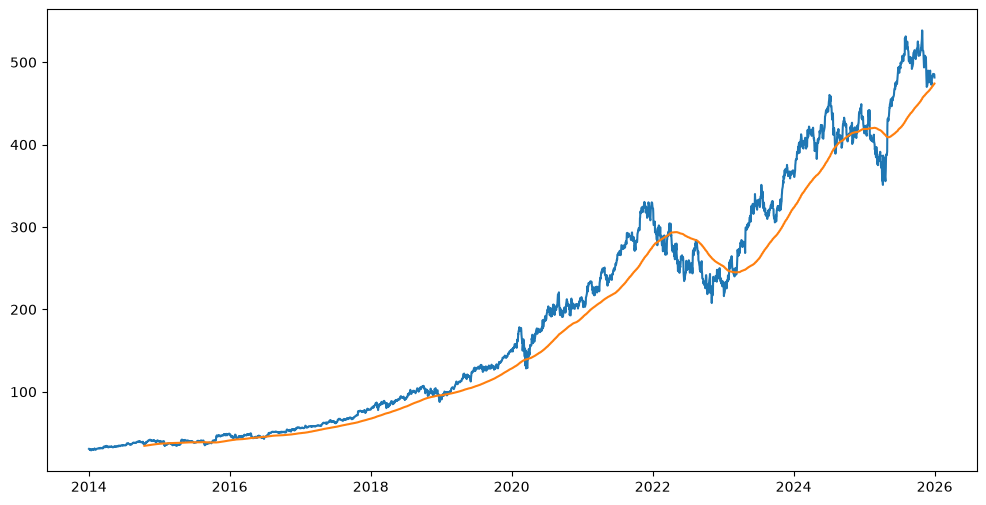

In [90]:
plt.figure(figsize=[12,6])
plt.plot(price.Close)
plt.plot(price.MA)

In [91]:
price['Sys_Ret'] = np.where(price.Long.shift(1) == True, price.Return, 1)

price['Sys_Bal'] = starting_balance * price.Sys_Ret.cumprod()

price

,Close,High,Low,Open,Volume,Return,Bench_Bal,Bench_Peak,Bench_DD,MA,Long,Sys_Ret,Sys_Bal
Date,,,,,,,,,,,,,
2014-01-02,30.694437,30.892680,30.644875,30.851377,30632200,1.000000,1000.000000,1000.000000,0.000000,NaN,False,1.000000,1000.000000
2014-01-03,30.487940,30.744003,30.231876,30.727483,31134800,0.993272,993.272488,1000.000000,-6.727512,NaN,False,1.000000,1000.000000
2014-01-06,29.843655,30.471419,29.827134,30.438378,43603700,0.978868,972.282196,1000.000000,-27.717804,NaN,False,1.000000,1000.000000
2014-01-07,30.074926,30.141008,29.909724,30.008847,35802800,1.007749,979.816843,1000.000000,-20.183157,NaN,False,1.000000,1000.000000
2014-01-08,29.538033,29.851916,29.389354,29.736276,59971700,0.982148,962.325274,1000.000000,-37.674726,NaN,False,1.000000,1000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,485.856323,486.991284,482.680464,483.526701,5855900,1.002403,15828.807116,17549.061703,-1720.254587,472.093603,True,1.002403,4804.386133
2025-12-26,485.547729,485.955915,483.805488,484.552163,8842200,0.999365,15818.753381,17549.061703,-1730.308323,472.623662,True,0.999365,4801.334606
2025-12-29,484.940430,486.184888,482.033362,482.710340,10893400,0.998749,15798.968043,17549.061703,-1750.093660,473.172964,True,0.998749,4795.329327


Finally, we compare our strategy's resulting balance to the benchmark balance.

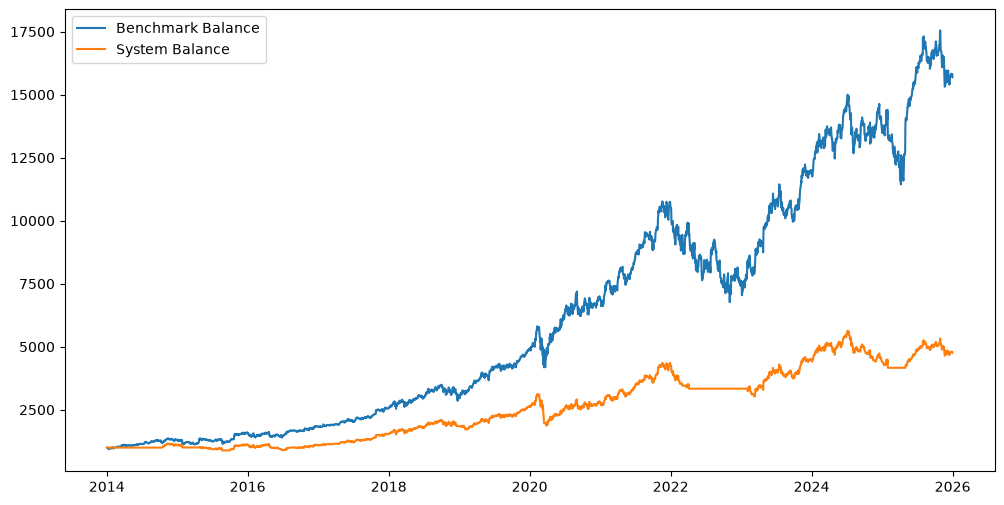

In [92]:
plt.figure(figsize=[12,6])
plt.plot(price.Bench_Bal, label="Benchmark Balance")
plt.plot(price.Sys_Bal, label = "System Balance")

plt.legend()
plt.show()